## Lab2 CNN. Frolova AI

You can choose any multi-label classification dataset for the following task.


1.   In this task you need to take a Fashion MNIST dataset and achieve **>85%** accuracy. You are able to improve the initial architecture using unused methods and tricks to improve the final result (max pooling, dropout, etc.). BUT do not make your model too complex (max 4 densed layers excluding convoltion and softmax layers).

2.  Explain what methods (or model additions) have had the biggest impact on the test set accuracy. Provide graphical comparison in metrics between models of different architectures.

3.  Train an additional architecture using any pretrained model to achieve comparable accuracy of **~85%** or higher. Try to beat a result obtained in the 1st task.

Requirements:

*   You should have your own classification layer (usually the last one) or layer that is responsible for classification. You can add a new layer if a classification layer is initially absent
*   You are able to choose at least one layer to retrain from the pretrained architecture
*   Architecture should beat the initial model in the 1st task
*   You  can choose any architecture from the pretrained list of [PyTorch](https://https://docs.pytorch.org/vision/main/models.html)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
from collections import defaultdict
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
print(f"Версия PyTorch: {torch.__version__}")

Используемое устройство: cpu
Версия PyTorch: 2.9.1+cpu


### Подготовка и загрузка данных

In [ ]:
def prepare_fashion_mnist(batch_size=64, val_split=0.1):
    """
    Загружает и подготавливает Fashion MNIST
    """
    # Аугментация для тренировочных данных
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.2859,), (0.3530,))  # Нормализация для Fashion MNIST
    ])
    
    # Только нормализация для тестовых данных
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2859,), (0.3530,))
    ])
    
    # Загрузка полного тренировочного набора Fashion MNIST
    full_train_dataset = datasets.FashionMNIST(
        root='./data_fashion', 
        train=True, 
        download=True, 
        transform=transform_train
    )
    
    # Разделение на тренировочный и валидационный наборы
    val_size = int(val_split * len(full_train_dataset))
    train_size = len(full_train_dataset) - val_size
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # Тестовый набор Fashion MNIST
    test_dataset = datasets.FashionMNIST(
        root='./data_fashion', 
        train=False, 
        download=True, 
        transform=transform_test
    )
    
    # Создание DataLoader'ов
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=2
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=2
    )
    
    # Классы
    classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')
    
    print(f"Fashion MNIST загружен:")
    print(f"  Тренировочные данные: {len(train_dataset)} изображений")
    print(f"  Валидационные данные: {len(val_dataset)} изображений")
    print(f"  Тестовые данные: {len(test_dataset)} изображений")
    
    return train_loader, val_loader, test_loader, classes

In [21]:
# Загрузка данных
train_loader, val_loader, test_loader, classes = prepare_fashion_mnist()

Fashion MNIST загружен:
  Тренировочные данные: 54000 изображений
  Валидационные данные: 6000 изображений
  Тестовые данные: 10000 изображений


In [22]:
def visualize_fashion_mnist(loader, classes, num_images=10):
    """
    Визуализирует Fashion MNIST
    """
    # Один батч
    dataiter = iter(loader)
    images, labels = next(dataiter)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    for i in range(num_images):
        img = images[i].numpy().squeeze()
        mean = 0.2859
        std = 0.3530
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"{classes[labels[i]]}", fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle("Примеры изображений", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

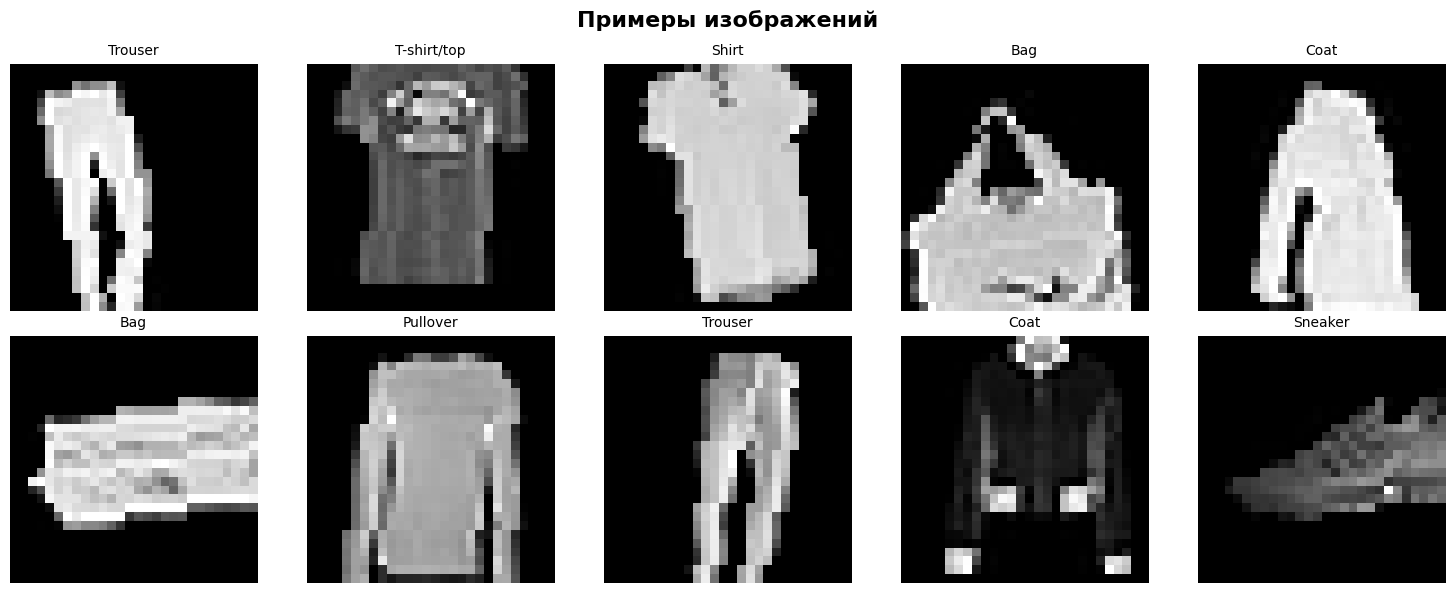

In [23]:
visualize_fashion_mnist(train_loader, classes)

## Базовая архитектура без улучшений

In [ ]:
class FashionCNN_Baseline(nn.Module):
    """
    Базовая CNN архитектура без улучшений
    """
    def __init__(self):
        super(FashionCNN_Baseline, self).__init__()
        
        # Свёрточные слои
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Pooling слой
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Полносвязные слои
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 10)  # 10 классов
        
    def forward(self, x):
        # Свёрточные слои
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # Выравнивание
        x = x.view(x.size(0), -1)
        
        # Полносвязные слои
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        
        return x

## Улучшенная архитектура

In [25]:
class FashionCNN_Improved(nn.Module):
    """
    Архитектура с BatchNorm, Dropout и дополнительными свёртками
    """
    def __init__(self, dropout_rate=0.5):
        super(FashionCNN_Improved, self).__init__()
        
        # Свёрточные слои с BatchNorm
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Pooling слой
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Полносвязные слои с Dropout
        self.fc1 = nn.Linear(128, 256)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout_rate * 0.7)
        
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)  # 10 классов
        
    def forward(self, x):
        # Свёрточные блоки
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Global Average Pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Полносвязные слои
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        
        return x

## Для обучения

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """
    
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Статистика
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """
    Валидация модели
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs=15, device=device, model_name="model"):
    """
    Полный цикл обучения модели
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rate': []
    }
    
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ МОДЕЛИ: {model_name}")
    print(f"{'='*60}")
    
    start_time = time.time()
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, criterion, 
                                            optimizer, device)
        
        # Валидация
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Записываем текущий LR
        current_lr = optimizer.param_groups[0]['lr']
        history['learning_rate'].append(current_lr)
        
        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}% | "
              f"Val: Loss={val_loss:.4f}, Acc={val_acc:.2f}% | "
              f"LR={current_lr:.6f}")
        
        # Сохранение лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, f'best_{model_name}.pth')
    
    training_time = time.time() - start_time
    print(f"\nОбучение завершено за {training_time:.2f} секунд")
    print(f"Лучшая валидационная точность: {best_val_acc:.2f}%")
    
    return history, best_val_acc

In [ ]:
def run_experiment_1():
    """
    Эксперимент 1: Сравнение базовой и улучшенной архитектур
    """
    print("\n" + "="*60)
    print("ЭКСПЕРИМЕНТ 1: Сравнение архитектур")
    print("="*60)
    
    results = {}
    
    # Базовая модель
    print("\n1. Базовая модель (без BatchNorm, Dropout):")
    model_baseline = FashionCNN_Baseline().to(device)
    optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    history_baseline, best_baseline = train_model(
        model_baseline, train_loader, val_loader, criterion, optimizer_baseline,
        num_epochs=15, device=device, model_name="baseline"
    )
    results['baseline'] = {'history': history_baseline, 'best_acc': best_baseline}
    
    # Улучшенная модель
    print("\n2. Улучшенная модель (с BatchNorm, Dropout, GAP):")
    model_improved = FashionCNN_Improved(dropout_rate=0.3).to(device)
    optimizer_improved = optim.Adam(model_improved.parameters(), lr=0.001, weight_decay=1e-4)
    
    history_improved, best_improved = train_model(
        model_improved, train_loader, val_loader, criterion, optimizer_improved,
        num_epochs=15, device=device, model_name="improved"
    )
    results['improved'] = {'history': history_improved, 'best_acc': best_improved}
    
    return results

In [ ]:
results_exp1 = run_experiment_1()


ЭКСПЕРИМЕНТ 1: Сравнение архитектур

1. Базовая модель (без BatchNorm, Dropout):

ОБУЧЕНИЕ МОДЕЛИ: baseline
Epoch  1/15 | Train: Loss=0.7570, Acc=70.88% | Val: Loss=0.6189, Acc=76.85% | LR=0.001000
Epoch  2/15 | Train: Loss=0.5027, Acc=80.95% | Val: Loss=0.4557, Acc=82.90% | LR=0.001000
Epoch  3/15 | Train: Loss=0.4277, Acc=84.01% | Val: Loss=0.3940, Acc=85.55% | LR=0.001000
Epoch  4/15 | Train: Loss=0.3812, Acc=85.80% | Val: Loss=0.3561, Acc=86.20% | LR=0.001000
Epoch  5/15 | Train: Loss=0.3560, Acc=86.71% | Val: Loss=0.3387, Acc=87.17% | LR=0.001000
Epoch  6/15 | Train: Loss=0.3326, Acc=87.56% | Val: Loss=0.3200, Acc=87.82% | LR=0.001000
Epoch  7/15 | Train: Loss=0.3161, Acc=88.31% | Val: Loss=0.3123, Acc=88.73% | LR=0.001000
Epoch  8/15 | Train: Loss=0.3064, Acc=88.63% | Val: Loss=0.3151, Acc=87.90% | LR=0.001000
Epoch  9/15 | Train: Loss=0.2908, Acc=89.27% | Val: Loss=0.2995, Acc=89.20% | LR=0.001000
Epoch 10/15 | Train: Loss=0.2867, Acc=89.51% | Val: Loss=0.2936, Acc=89.15% | LR=

In [ ]:
def plot_architecture_comparison(results):
    """
    Графическое сравнение разных архитектур
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Сравнение точности
    axes[0, 0].plot(results['baseline']['history']['val_acc'], 
                   label='Базовая', linewidth=2, marker='o', markersize=4)
    axes[0, 0].plot(results['improved']['history']['val_acc'], 
                   label='Улучшенная', linewidth=2, marker='s', markersize=4)
    axes[0, 0].set_xlabel('Эпоха')
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].set_title('Сравнение точности на валидации')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Сравнение LOSS
    axes[0, 1].plot(results['baseline']['history']['val_loss'], 
                   label='Базовая', linewidth=2, marker='o', markersize=4)
    axes[0, 1].plot(results['improved']['history']['val_loss'], 
                   label='Улучшенная', linewidth=2, marker='s', markersize=4)
    axes[0, 1].set_xlabel('Эпоха')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Сравнение функции потерь на валидации')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Сравнение точности на тренировке
    axes[1, 0].plot(results['baseline']['history']['train_acc'], 
                   label='Базовая', linewidth=2, alpha=0.7)
    axes[1, 0].plot(results['improved']['history']['train_acc'], 
                   label='Улучшенная', linewidth=2, alpha=0.7)
    axes[1, 0].set_xlabel('Эпоха')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].set_title('Точность на тренировке')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Сравнение лучших accuracy
    models_names = ['Базовая', 'Улучшенная']
    best_accs = [results['baseline']['best_acc'], results['improved']['best_acc']]
    
    bars = axes[1, 1].bar(models_names, best_accs, color=['skyblue', 'lightgreen'])
    axes[1, 1].set_ylabel('Лучшая Accuracy (%)')
    axes[1, 1].set_title('Сравнение лучших accuracy')
    axes[1, 1].set_ylim(0, 100)
    
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle('Сравнение архитектур CNN для Fashion MNIST', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return best_accs

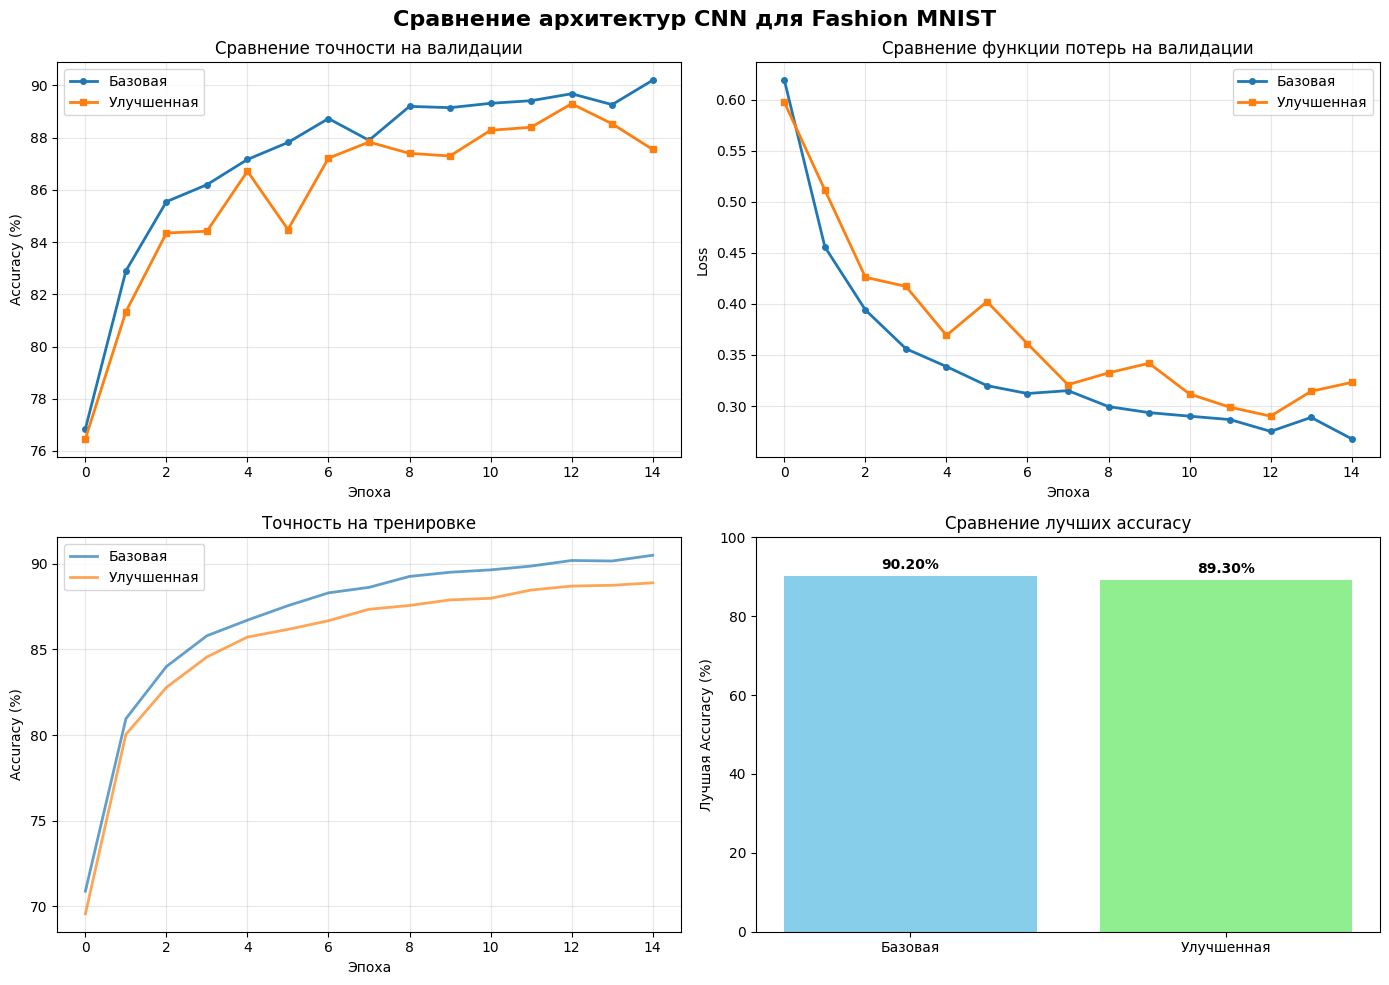

In [30]:
# Визуализируем сравнение
best_accs_exp1 = plot_architecture_comparison(results_exp1)


ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ (Улучшенная CNN)

Результаты на тестовом наборе:
Точность: 89.73%
Правильных: 8973/10000

Accuracy >85% (89.73%)


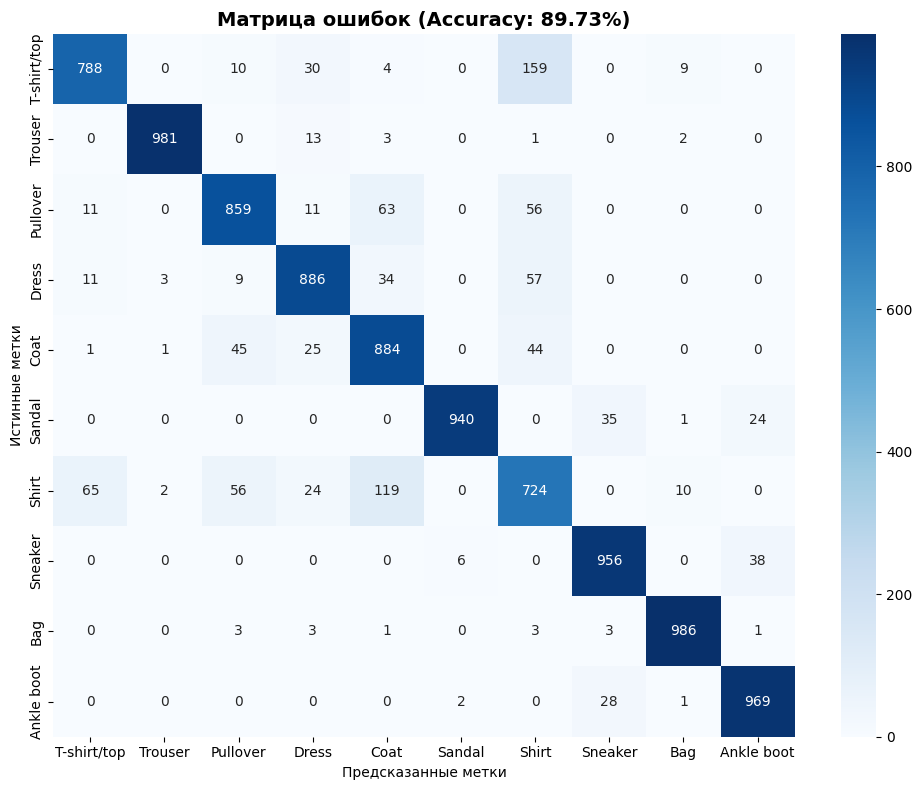


Отчет по классам:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.79      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.87      0.86      0.87      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.80      0.88      0.84      1000
      Sandal       0.99      0.94      0.97      1000
       Shirt       0.69      0.72      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.94      0.97      0.95      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [38]:
def test_best_model_exp1():
    """
    Тестирование лучшей модели
    """
    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ (Улучшенная CNN)")
    print("="*60)
    
    # Загружаем лучшую модель
    model = FashionCNN_Improved(dropout_rate=0.3).to(device)
    checkpoint = torch.load('best_improved.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Тестирование
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100. * correct / total
    print(f"\nРезультаты на тестовом наборе:")
    print(f"Точность: {accuracy:.2f}%")
    print(f"Правильных: {correct}/{total}")
    
    if accuracy > 85:
        print(f"\nAccuracy >85% ({accuracy:.2f}%)")
    else:
        print(f"\nAccuracy <85% ({accuracy:.2f}%)")
    
    # Матрица ошибок
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Матрица ошибок (Accuracy: {accuracy:.2f}%)', fontsize=14, fontweight='bold')
    plt.ylabel('Истинные метки')
    plt.xlabel('Предсказанные метки')
    plt.tight_layout()
    plt.show()
    
    # Отчет по классам
    print("\nОтчет по классам:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    return accuracy, all_preds, all_labels

# Тестируем лучшую модель
test_accuracy_exp1, preds_exp1, labels_exp1 = test_best_model_exp1()

In [ ]:
class PretrainedFashionModel(nn.Module):
    """
    Pretrained модель (ResNet18) с fine-tuning для Fashion MNIST
    """
    def __init__(self, num_classes=10, freeze_layers=True):
        super(PretrainedFashionModel, self).__init__()
        
        # Загружаем pretrained ResNet18
        self.resnet = models.resnet18(pretrained=True)
        
        # Замораживаем все слои изначально
        if freeze_layers:
            for param in self.resnet.parameters():
                param.requires_grad = False
        
        # Размораживаем последние 2 блока для fine-tuning
        for param in self.resnet.layer3.parameters():
            param.requires_grad = True
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True
        
        # Заменяем последний слой на свой
        num_features = self.resnet.fc.in_features
        
        # 
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, num_classes)  # 10 классов
        )
        
        # Адаптивный pooling для изменения размера
        self.adaptive_pool = nn.AdaptiveAvgPool2d((224, 224))
        
    def forward(self, x):
        # ResNet ожидает 3 канала, а Fashion MNIST - 1 канал
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)  # [B, 1, 28, 28] -> [B, 3, 28, 28]
        
        # ResNet ожидает изображения 224x224
        x = self.adaptive_pool(x)  # [B, 3, 28, 28] -> [B, 3, 224, 224]
        
        return self.resnet(x)

def train_pretrained_model():
    """
    Обучение pretrained модели
    """
    print("\n" + "="*60)
    print("ЗАДАНИЕ 2: Обучение Pretrained модели (ResNet18)")
    print("="*60)
    
    # Создаем модель
    model = PretrainedFashionModel().to(device)
    
    # Считаем trainable параметры
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\nИнформация о модели:")
    print(f"  Архитектура: ResNet18 (pretrained)")
    print(f"  Всего параметров: {total_params:,}")
    print(f"  Обучаемых параметров: {trainable_params:,}")
    print(f"  Процент обучаемых: {100*trainable_params/total_params:.1f}%")
    
    # Показываем, какие слои обучаются
    print("\nСлои, которые будут обучаться (fine-tuning):")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"  ✓ {name}")
    
    # Оптимизатор только для обучаемых параметров
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.0001,
        weight_decay=1e-4
    )
    
    criterion = nn.CrossEntropyLoss()
    
    # Обучение
    print("\nНачало обучения pretrained модели...")
    history, best_val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=10,  # Меньше эпох, т.к. pretrained
        device=device,
        model_name="pretrained"
    )
    
    return model, history, best_val_acc

# Обучаем pretrained модель
pretrained_model, pretrained_history, pretrained_best_val = train_pretrained_model()    


ЗАДАНИЕ 2: Обучение Pretrained модели (ResNet18)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 24.5MB/s]



Информация о модели:
  Архитектура: ResNet18 (pretrained)
  Всего параметров: 11,606,218
  Обучаемых параметров: 10,923,146
  Процент обучаемых: 94.1%

Слои, которые будут обучаться (fine-tuning):
  ✓ resnet.layer3.0.conv1.weight
  ✓ resnet.layer3.0.bn1.weight
  ✓ resnet.layer3.0.bn1.bias
  ✓ resnet.layer3.0.conv2.weight
  ✓ resnet.layer3.0.bn2.weight
  ✓ resnet.layer3.0.bn2.bias
  ✓ resnet.layer3.0.downsample.0.weight
  ✓ resnet.layer3.0.downsample.1.weight
  ✓ resnet.layer3.0.downsample.1.bias
  ✓ resnet.layer3.1.conv1.weight
  ✓ resnet.layer3.1.bn1.weight
  ✓ resnet.layer3.1.bn1.bias
  ✓ resnet.layer3.1.conv2.weight
  ✓ resnet.layer3.1.bn2.weight
  ✓ resnet.layer3.1.bn2.bias
  ✓ resnet.layer4.0.conv1.weight
  ✓ resnet.layer4.0.bn1.weight
  ✓ resnet.layer4.0.bn1.bias
  ✓ resnet.layer4.0.conv2.weight
  ✓ resnet.layer4.0.bn2.weight
  ✓ resnet.layer4.0.bn2.bias
  ✓ resnet.layer4.0.downsample.0.weight
  ✓ resnet.layer4.0.downsample.1.weight
  ✓ resnet.layer4.0.downsample.1.bias
  ✓ resn

In [ ]:
def test_pretrained_model():
    """
    Тестирование pretrained модели
    """
    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ PRETRAINED МОДЕЛИ")
    print("="*60)
    
    # Загружаем лучшую версию
    checkpoint = torch.load('best_pretrained.pth')
    pretrained_model.load_state_dict(checkpoint['model_state_dict'])
    
    # Тестирование
    pretrained_model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        correct = 0
        total = 0
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = pretrained_model(inputs)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100. * correct / total
    print(f"\nРезультаты pretrained модели на тестовом наборе:")
    print(f"Точность: {accuracy:.2f}%")
    print(f"Правильных: {correct}/{total}")
    
    return accuracy, all_preds, all_labels

# Тестируем модель
pretrained_accuracy, pretrained_preds, pretrained_labels = test_pretrained_model()


ТЕСТИРОВАНИЕ PRETRAINED МОДЕЛИ

Результаты pretrained модели на тестовом наборе:
Точность: 94.03%
Правильных: 9403/10000


In [41]:
def compare_all_models():
    """
    Финальное сравнение всех моделей
    """
    
    # Данные для сравнения
    comparison_data = {
        'Модель': ['Базовая CNN', 'Улучшенная CNN', 'Pretrained ResNet18'],
        'Accuracy (%)': [
            results_exp1['baseline']['best_acc'],
            test_accuracy_exp1,
            pretrained_accuracy
        ]
    }
    
    df_comparison = pd.DataFrame(comparison_data)
    
    # Выводим таблицу
    print("\nСравнение моделей:")
    print(df_comparison.to_string(index=False))
    
    # График сравнения accuracy
    plt.figure(figsize=(10, 6))
    models = df_comparison['Модель']
    accuracies = df_comparison['Accuracy (%)']
    
    bars = plt.bar(models, accuracies, color=['lightblue', 'lightgreen', 'salmon'])
    plt.ylabel('Accuracy (%)')
    plt.title('Сравнение accuracy разных моделей', fontsize=14, fontweight='bold')
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    
    # Добавляем значения и цели
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    # Линия цели 85%
    plt.axhline(y=85, color='red', linestyle='--', alpha=0.7, label='Цель: 85%')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


Сравнение моделей:
             Модель  Accuracy (%)
        Базовая CNN         90.20
     Улучшенная CNN         89.73
Pretrained ResNet18         94.03


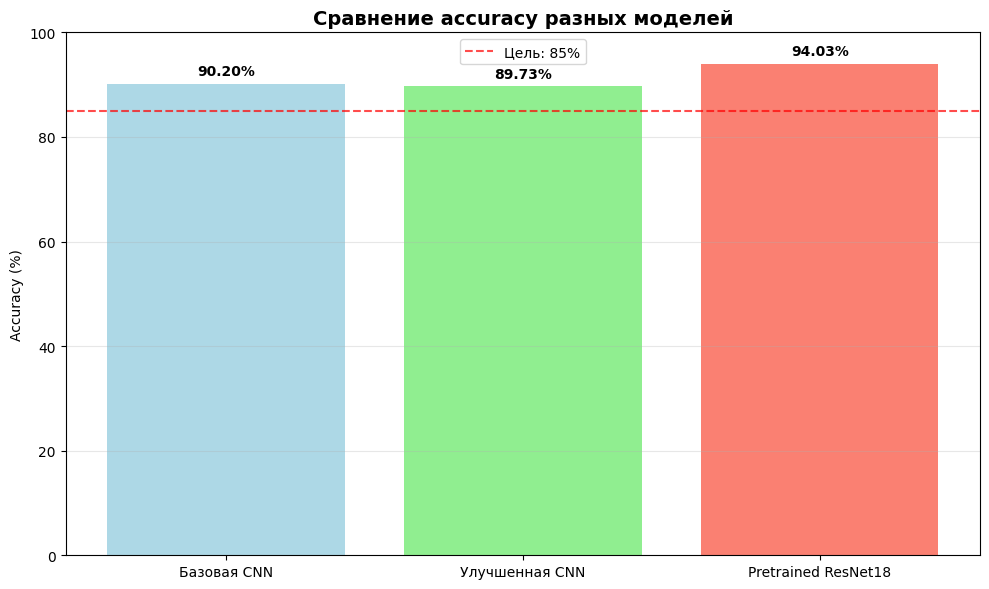

In [42]:
final_comparison = compare_all_models()

## Ошибки классификации


АНАЛИЗ ОШИБОК КЛАССИФИКАЦИИ


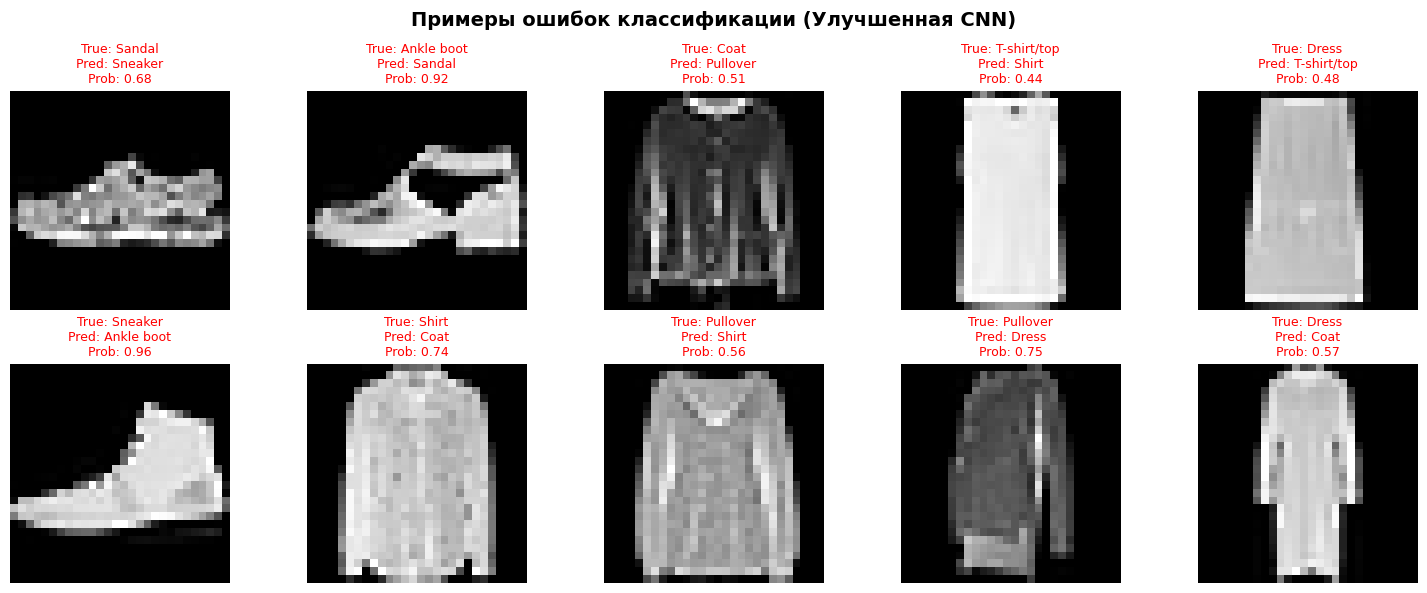


Анализ ошибок для Улучшенная CNN:
Самые частые ошибки:
  Coat -> Pullover: 2 раз
  Shirt -> Coat: 2 раз
  Sandal -> Sneaker: 1 раз
  Ankle boot -> Sandal: 1 раз
  T-shirt/top -> Shirt: 1 раз


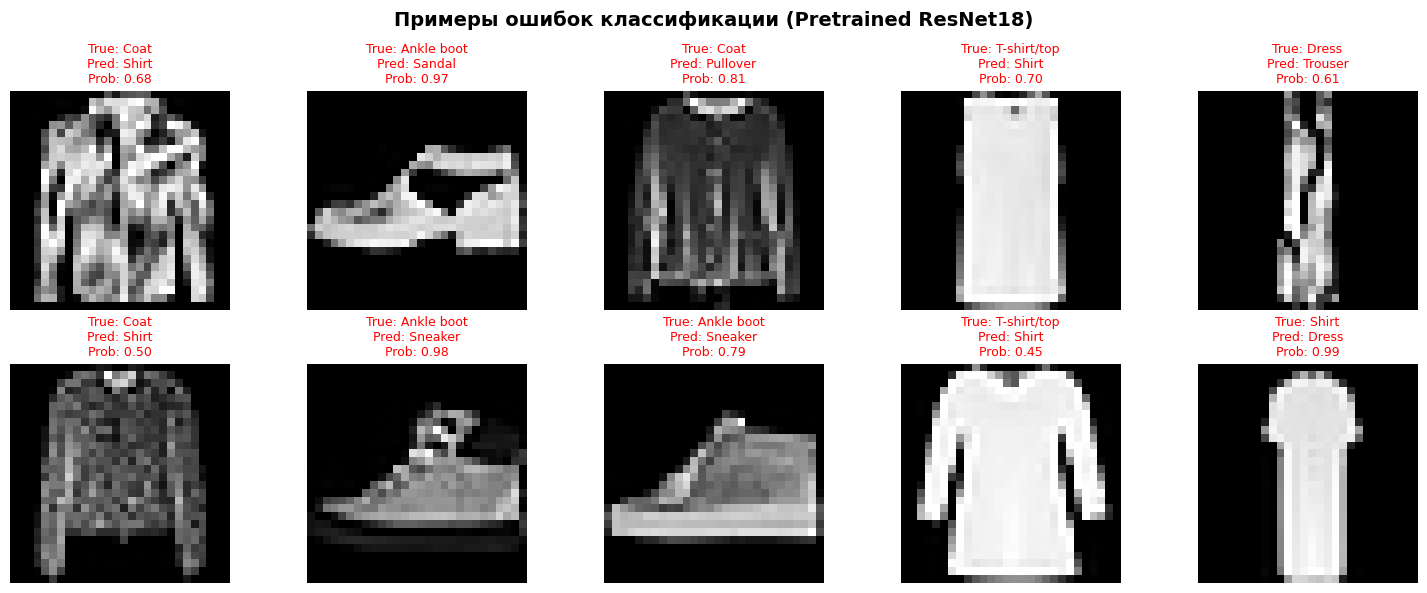


Анализ ошибок для Pretrained ResNet18:
Самые частые ошибки:
  Coat -> Shirt: 2 раз
  T-shirt/top -> Shirt: 2 раз
  Ankle boot -> Sneaker: 2 раз
  Ankle boot -> Sandal: 1 раз
  Coat -> Pullover: 1 раз


In [43]:
def visualize_errors(model, loader, classes, model_name="Model"):
    """
    Визуализация примеров ошибок классификации
    """
    model.eval()
    errors = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            for i in range(len(labels)):
                if predicted[i] != labels[i]:
                    errors.append({
                        'image': inputs[i].cpu(),
                        'true': labels[i].item(),
                        'pred': predicted[i].item(),
                        'true_prob': F.softmax(outputs[i], dim=0)[labels[i]].item(),
                        'pred_prob': F.softmax(outputs[i], dim=0)[predicted[i]].item()
                    })
            
            if len(errors) >= 10:
                break
    
    # Визуализация ошибок
    if errors:
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.ravel()
        
        for i in range(min(10, len(errors))):
            error = errors[i]
            img = error['image'].numpy().squeeze()
            
            # Денормализация
            mean = 0.2859
            std = 0.3530
            img = std * img + mean
            img = np.clip(img, 0, 1)
            
            axes[i].imshow(img, cmap='gray')
            title = f"True: {classes[error['true']]}\n"
            title += f"Pred: {classes[error['pred']]}\n"
            title += f"Prob: {error['pred_prob']:.2f}"
            axes[i].set_title(title, fontsize=9, color='red')
            axes[i].axis('off')
        
        plt.suptitle(f'Примеры ошибок классификации ({model_name})', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # Анализ типичных ошибок
    if errors:
        print(f"\nАнализ ошибок для {model_name}:")
        error_pairs = [(classes[e['true']], classes[e['pred']]) for e in errors[:20]]
        from collections import Counter
        common_errors = Counter(error_pairs).most_common(5)
        
        print("Самые частые ошибки:")
        for (true, pred), count in common_errors:
            print(f"  {true} -> {pred}: {count} раз")

# Визуализируем ошибки для обеих моделей
print("\n" + "="*60)
print("АНАЛИЗ ОШИБОК КЛАССИФИКАЦИИ")
print("="*60)

# Загружаем модели
model_improved = FashionCNN_Improved().to(device)
checkpoint_improved = torch.load('best_improved.pth')
model_improved.load_state_dict(checkpoint_improved['model_state_dict'])

visualize_errors(model_improved, test_loader, classes, "Улучшенная CNN")
visualize_errors(pretrained_model, test_loader, classes, "Pretrained ResNet18")
